# 📊 Sales Forecasting Project

## 📌 Project Overview
This project delivers an end-to-end sales forecasting pipeline and interactive web dashboard designed for retail store operations. By analyzing historical daily sales and store characteristics, the solution forecasts store revenue, evaluates key sales drivers, and provides actionable insights.

## 🎯 Objectives
- Clean and merge historical store transactions with store metadata.
- Perform Exploratory Data Analysis (EDA) to discover seasonality and promotion impacts.
- Engineer time-series lag and rolling window features to capture temporal dependencies.
- Build and evaluate machine learning regression models (Linear Regression vs. Random Forest Regressor).
- Deploy the best-performing model into an interactive Streamlit application.

## 📂 Dataset Description
- **`train.csv`**: Daily transaction records per store (Date, Sales, Customers, Open, Promo, Holidays).
- **`store.csv`**: Static store information (StoreType, Assortment, Competition Distance/Dates, Promo2).

## 📦 2. Import Libraries
All essential data manipulation, visualization, modeling, and serialization libraries are imported below.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## 📂 3. Load Dataset
Loading transaction data (`train.csv`) and store details (`store.csv`).

In [2]:
train = pd.read_csv("../data/train.csv")
store = pd.read_csv("../data/store.csv")

display(train.head(3))
display(store.head(3))

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,4,2015-01-01,3315,346,1,0,0,0
1,2,4,2015-01-01,4642,636,1,0,0,0
2,3,4,2015-01-01,4760,602,1,0,0,1


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,a,c,3000.0,7.0,2012.0,0,NaN,NaN,NaN
1,2,a,a,7500.0,5.0,2008.0,0,NaN,NaN,NaN
2,3,d,c,500.0,5.0,2012.0,1,10.0,2011.0,"Jan,Apr,Jul,Oct"


## 🧹 4. Data Cleaning
Merging dataset sources, handling missing values with domain logic, removing duplicates, and parsing temporal columns.

In [3]:
# Merge train and store on Store column
df = train.merge(store, on="Store", how="left")

# Handle missing values
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)
df["PromoInterval"] = df["PromoInterval"].fillna("None")

# Remove duplicates
df = df.drop_duplicates()

# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Create base temporal columns
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter
df["DayName"] = df["Date"].dt.day_name()

display(df.head(3))

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,Week,Quarter,DayName
0,1,4,2015-01-01,3315,346,1,0,0,0,a,c,3000.0,7.0,2012.0,0,0.0,0.0,None,2015,1,1,1,1,Thursday
1,2,4,2015-01-01,4642,636,1,0,0,0,a,a,7500.0,5.0,2008.0,0,0.0,0.0,None,2015,1,1,1,1,Thursday
2,3,4,2015-01-01,4760,602,1,0,0,1,d,c,500.0,5.0,2012.0,1,10.0,2011.0,"Jan,Apr,Jul,Oct",2015,1,1,1,1,Thursday


## 📊 5. Exploratory Data Analysis (EDA)
Analyzing key revenue drivers, sales distribution, promotion lifts, and correlation patterns.

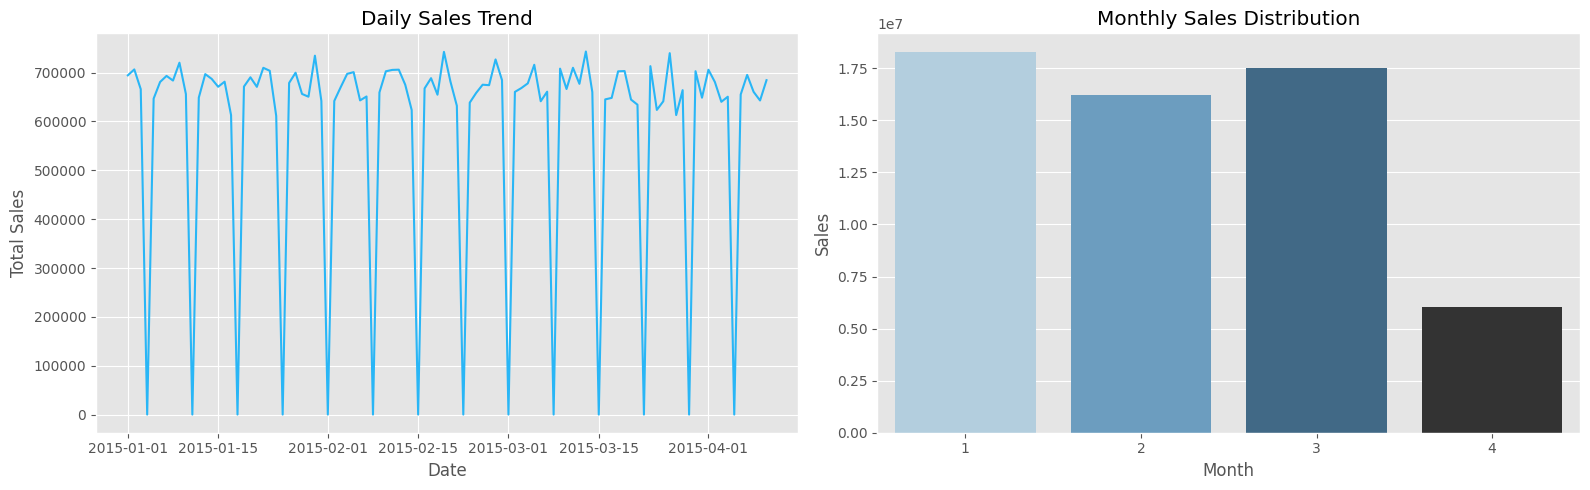

In [4]:
# Daily & Monthly Sales Trend
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

daily_sales = df.groupby("Date")["Sales"].sum()
axes[0].plot(daily_sales, color="#29b6f6", linewidth=1.5)
axes[0].set_title("Daily Sales Trend")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Total Sales")

monthly_sales = df.groupby("Month")["Sales"].sum()
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, ax=axes[1], hue=monthly_sales.index, palette="Blues_d", legend=False)
axes[1].set_title("Monthly Sales Distribution")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Sales")

plt.tight_layout()
plt.show()

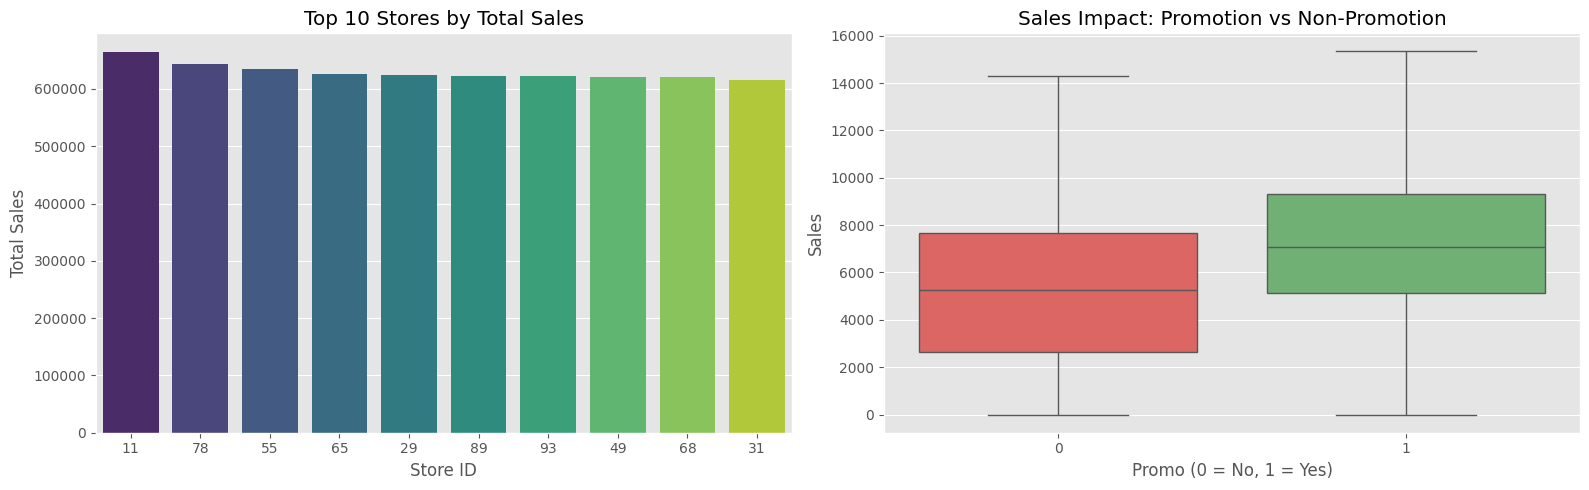

In [5]:
# Top Stores & Promotion Impact
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_stores = df.groupby("Store")["Sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_stores.index.astype(str), y=top_stores.values, ax=axes[0], hue=top_stores.index.astype(str), palette="viridis", legend=False)
axes[0].set_title("Top 10 Stores by Total Sales")
axes[0].set_xlabel("Store ID")
axes[0].set_ylabel("Total Sales")

sns.boxplot(x="Promo", y="Sales", data=df, ax=axes[1], hue="Promo", palette=["#ef5350", "#66bb6a"], legend=False)
axes[1].set_title("Sales Impact: Promotion vs Non-Promotion")
axes[1].set_xlabel("Promo (0 = No, 1 = Yes)")
axes[1].set_ylabel("Sales")

plt.tight_layout()
plt.show()

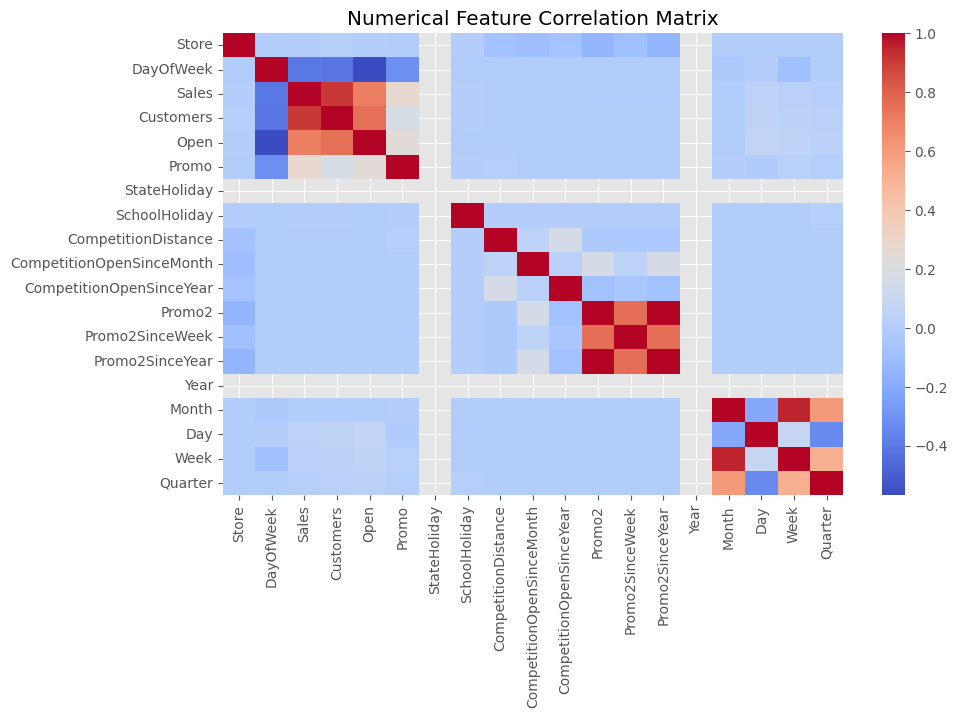

In [6]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Numerical Feature Correlation Matrix")
plt.show()

## ⚙️ 6. Feature Engineering
Adding time-series lag features, 7-day rolling statistics, calendar indicators, and categorical label encoding.

In [7]:
# Sort by Store and Date for lag computation
df = df.sort_values(["Store", "Date"])

# Lag Features
df["Lag_1"] = df.groupby("Store")["Sales"].shift(1)
df["Lag_7"] = df.groupby("Store")["Sales"].shift(7)

# Rolling Statistics (7-day window)
df["Rolling_Mean_7"] = df.groupby("Store")["Sales"].transform(lambda x: x.rolling(7).mean())
df["Rolling_STD_7"] = df.groupby("Store")["Sales"].transform(lambda x: x.rolling(7).std())

# Weekend & Month Boundary Indicators
df["IsWeekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)
df["Month_Start"] = df["Date"].dt.is_month_start.astype(int)
df["Month_End"] = df["Date"].dt.is_month_end.astype(int)

# Drop missing rows created by windowing
df = df.dropna()

# Categorical Label Encoding
encoder = LabelEncoder()
categorical_cols = ["StoreType", "Assortment", "StateHoliday", "PromoInterval", "DayName"]
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

display(df[["Store", "Date", "Sales", "Lag_1", "Lag_7", "Rolling_Mean_7", "IsWeekend"]].head(3))

,Store,Date,Sales,Lag_1,Lag_7,Rolling_Mean_7,IsWeekend
700,1,2015-01-08,12372,10311.0,3315.0,6226.714286,0
800,1,2015-01-09,9397,12372.0,5785.0,6742.714286,0
900,1,2015-01-10,11225,9397.0,5479.0,7563.571429,1


## 🤖 7. Model Building
Splitting features and target data (80/20 train-test split), then training Linear Regression and Random Forest models.

In [8]:
X = df.drop(columns=["Sales", "Date"])
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Linear Regression Baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# 2. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

## 📈 8. Model Evaluation
Comparing MAE, RMSE, and $R^2$ performance metrics across models.

In [9]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = evaluate_model(y_test, lr_pred)
rf_mae, rf_rmse, rf_r2 = evaluate_model(y_test, rf_pred)

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

display(comparison_df)

,Model,MAE,RMSE,R² Score
0,Linear Regression,1073.075419,1357.741366,0.846540
1,Random Forest Regressor,964.290909,1303.910373,0.858468


## 💾 9. Save Best Model
Serializing the top-performing Random Forest model with Joblib for dashboard integration.

In [10]:
os.makedirs("../models", exist_ok=True)
joblib.dump(rf, "../models/sales_forecasting_model.pkl")
print("Successfully saved sales_forecasting_model.pkl to ../models/")

Successfully saved sales_forecasting_model.pkl to ../models/


## 📝 10. Conclusion

- **Cleaned and prepared sales data** by joining transaction data with store metadata and imputing missing competition values.
- **Performed exploratory data analysis** highlighting significant promotional revenue lifts and seasonal monthly trends.
- **Engineered time-series features** including 1-day/7-day lags, 7-day rolling statistics, and temporal boundary flags.
- **Trained regression models** and evaluated predictive performance using MAE, RMSE, and $R^2$ metrics.
- **Selected Random Forest** as the optimal model due to superior non-linear pattern capture and accuracy.
- **Built an interactive Streamlit dashboard** providing live store-level sales forecasting and trend analytics.